In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

I). Ziel und Fragestellungen


In [3]:

# Ziel und Fragestellungen: Verkaufsanalyse von Videospielen (E-Commerce)

'''Ziele: 
	Marktverhalten global und regional verstehen
	Einfluss von Bewertungen auf Verkaufszahlen untersuchen
	Erfolgreiche Genres, Publisher & Plattformen identifizieren
	Zeitliche Trends und Entwicklungen im Spielemarkt analysieren
	Qualität und Lücken in den Daten bewerten

# Fragestellungen: 
	Welches Videospielt ist am meisten verkauft?
    Wo ist der größte Verkauf?
    welches Videospielt hat die beste Bewertung?
	Welcher Entwickler ist beliebt?
'''

'Ziele: \n\tMarktverhalten global und regional verstehen\n\tEinfluss von Bewertungen auf Verkaufszahlen untersuchen\n\tErfolgreiche Genres, Publisher & Plattformen identifizieren\n\tZeitliche Trends und Entwicklungen im Spielemarkt analysieren\n\tQualität und Lücken in den Daten bewerten\n\n# Fragestellungen: \n\tWelches Videospielt ist am meisten verkauft?\n    Wo ist der größte Verkauf?\n    welches Videospielt hat die beste Bewertung?\n\tWelcher Entwickler ist beliebt?\n'

II). Daten einlesen und prüfen



In [4]:
# Daten einlesen

vid_game_sales = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')
vid_game_sales

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Daten prüfen

vid_game_sales.shape    # die Methode shape zeigt die Zeilen und Spalten in unser Datei

(16719, 16)

In [6]:
print(vid_game_sales.info())      # die Funktion info() gibt einen oberflächlichen Überblick über unsere Daten.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB
None


In [7]:
vid_game_sales.head()                # head() zeigt automatisch(sort_index) die erste 5 Zeilen unserer Datei

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
vid_game_sales.sample(20)   

# sample() zeigt zufällig 10 Zeilen in unserer Datei (Einen ersten Eindruck von Daten bekommen, Testen, ob bestimmte Spalten korrekt befüllt sind.)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
4321,Scooby-Doo! and the Spooky Swamp,Wii,2010.0,Action,Warner Bros. Interactive Entertainment,0.29,0.13,0.00,0.04,0.45,NaN,NaN,NaN,NaN,NaN,NaN
1575,Brian Lara Cricket,PS,1998.0,Sports,Codemasters,0.02,1.13,0.01,0.10,1.26,NaN,NaN,NaN,NaN,NaN,NaN
13711,Fashion Week Jr. Designer,DS,2009.0,Simulation,505 Games,0.04,0.00,0.00,0.00,0.04,NaN,NaN,tbd,NaN,505 Games,E
9975,DEATH NOTE: Kira Game,DS,2007.0,Adventure,Konami Digital Entertainment,0.00,0.00,0.12,0.00,0.12,NaN,NaN,NaN,NaN,NaN,NaN
4457,Spider-Man: Shattered Dimensions,PS3,2010.0,Action,Activision,0.26,0.12,0.00,0.05,0.44,74.0,57.0,7.5,96.0,Beenox,T
11707,Majin Tensei,SNES,1994.0,Role-Playing,Atlus,0.00,0.00,0.08,0.00,0.08,NaN,NaN,NaN,NaN,NaN,NaN
13952,Countdown Vampires,PS,1999.0,Adventure,Namco Bandai Games,0.02,0.01,0.00,0.00,0.04,41.0,6.0,tbd,NaN,K2 LLC,M
5518,Naruto: Gekito Ninja Taisen! 4,GC,2005.0,Fighting,Tomy Corporation,0.00,0.00,0.32,0.01,0.33,NaN,NaN,NaN,NaN,NaN,NaN
12848,Amazing Island,GC,2004.0,Strategy,Sega,0.04,0.01,0.00,0.00,0.06,59.0,22.0,6.6,7.0,Hitmaker,E
16683,XI Coliseum,PSP,2006.0,Puzzle,Sony Computer Entertainment,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# die Funktion describe() zeigt die erste statistische Werte von unseren Daten.

vid_game_sales.describe()              

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [10]:
vid_game_sales.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [11]:
vid_game_sales

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


III). Daten Bereinigung

In [12]:
# Spalte formatieren

# 1.) Year_of_release in Datetime formatieren
vid_game_sales['Year_of_Release'] = pd.to_datetime(vid_game_sales['Year_of_Release'], format='%Y', errors='coerce')
vid_game_sales

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006-01-01,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016-01-01,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003-01-01,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
kopie = vid_game_sales.copy()

In [14]:
# Spaltennamen Abkürzungen definieren

''' NA_Sales = Nord-Amerika_Verkäufe
    EU_Sales = Europe_Verkäufe
    JP_Sales = Japan_Verkäufe
'''

''' E = Jeder (ab 6+)
    T = Jugendlicher (ab 13+)
    M = Erwachsener (ab 17+)
'''


' E = Jeder (ab 6+)\n    T = Jugendlicher (ab 13+)\n    M = Erwachsener (ab 17+)\n'

In [15]:
# Spaltennamen umbenennen

deutsche_spalten = {
    'Name': 'Spielname',
    'Platform': 'Plattform',
    'Year_of_Release': 'Erscheinungsjahr',
    'Genre': 'Genre',
    'Publisher': 'Herausgeber',
    'NA_Sales': 'Verkäufe_Nordamerika_Mio',
    'EU_Sales': 'Verkäufe_Europa_Mio',
    'JP_Sales': 'Verkäufe_Japan_Mio',
    'Other_Sales': 'Verkäufe_andere_Märkte_Mio',
    'Global_Sales': 'Weltweite_Verkäufe_Mio',
    'Critic_Score': 'Kritiker_Bewertung',
    'Critic_Count': 'Anzahl_Kritiken',
    'User_Score': 'Nutzer_Bewertung',
    'User_Count': 'Anzahl_Nutzerbewertungen',
    'Developer': 'Entwickler',
    'Rating': 'Altersfreigabe'
}

vid_game_sales.rename(columns=deutsche_spalten, inplace=True)
vid_game_sales



,Spielname,Plattform,Erscheinungsjahr,Genre,Herausgeber,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio,Kritiker_Bewertung,Anzahl_Kritiken,Nutzer_Bewertung,Anzahl_Nutzerbewertungen,Entwickler,Altersfreigabe
0,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006-01-01,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016-01-01,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003-01-01,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Fehlende Werte suchen ( mit der Methode isnull())

fehlende_werte = vid_game_sales.isnull().sum()
fehlende_werte

Spielname                        2
Plattform                        0
Erscheinungsjahr               269
Genre                            2
Herausgeber                     54
Verkäufe_Nordamerika_Mio         0
Verkäufe_Europa_Mio              0
Verkäufe_Japan_Mio               0
Verkäufe_andere_Märkte_Mio       0
Weltweite_Verkäufe_Mio           0
Kritiker_Bewertung            8582
Anzahl_Kritiken               8582
Nutzer_Bewertung              6704
Anzahl_Nutzerbewertungen      9129
Entwickler                    6623
Altersfreigabe                6769
dtype: int64

In [17]:
vid_game_sales.columns

Index(['Spielname', 'Plattform', 'Erscheinungsjahr', 'Genre', 'Herausgeber',
       'Verkäufe_Nordamerika_Mio', 'Verkäufe_Europa_Mio', 'Verkäufe_Japan_Mio',
       'Verkäufe_andere_Märkte_Mio', 'Weltweite_Verkäufe_Mio',
       'Kritiker_Bewertung', 'Anzahl_Kritiken', 'Nutzer_Bewertung',
       'Anzahl_Nutzerbewertungen', 'Entwickler', 'Altersfreigabe'],
      dtype='object')

In [18]:
# Spalten bereinigen und löschen
# unnötige Spalten löschen mit der Methode drop

vid_game_sales.drop(columns=['Altersfreigabe', 'Vor_2000', 'Nach_2000', 'Anzahl_Kritiken', 'Anzahl_Nutzerbewertungen'], inplace=True)



KeyError: "['Vor_2000', 'Nach_2000'] not found in axis"

In [ ]:
# Spalten ausffülen mit der Methode fillna

spalten = ['Anzahl_Kritiken', 'Anzahl_Nutzerbewertungen', 'Erscheinungsjahr','Spielname', 'Genre', 'Herausgeber']
vid_game_sales[spalten] = vid_game_sales[spalten].fillna(0)



In [ ]:
# unnötige Spalten löschen mit der Methode drop

vid_game_sales.drop(columns=['Altersfreigabe', 'Anzahl_Kritiken', 'Anzahl_Nutzerbewertungen'], inplace=True)

KeyError: "['Altersfreigabe', 'Anzahl_Kritiken', 'Anzahl_Nutzerbewertungen'] not found in axis"

In [ ]:
kopie2 = vid_game_sales.copy()
kopie2

,Spielname,Plattform,Erscheinungsjahr,Genre,Herausgeber,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio,Kritiker_Bewertung,Anzahl_Kritiken,Nutzer_Bewertung,Anzahl_Nutzerbewertungen,Entwickler,Altersfreigabe
0,Wii Sports,Wii,2006-01-01 00:00:00,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985-01-01 00:00:00,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,0.0,NaN,0.0,NaN,NaN
2,Mario Kart Wii,Wii,2008-01-01 00:00:00,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009-01-01 00:00:00,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996-01-01 00:00:00,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,0.0,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01 00:00:00,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,0.0,NaN,0.0,NaN,NaN
16715,LMA Manager 2007,X360,2006-01-01 00:00:00,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,0.0,NaN,0.0,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016-01-01 00:00:00,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,0.0,NaN,0.0,NaN,NaN
16717,Spirits & Spells,GBA,2003-01-01 00:00:00,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,0.0,NaN,0.0,NaN,NaN


In [ ]:
# Duplikate aussuchen
vid_game_sales.duplicated().sum()

np.int64(0)

In [ ]:
vid_game_sales

NameError: name 'vid_game_sales' is not defined

IV) Deskriptive Analyse

In [ ]:
# Welweit_Verkäufe über Jahr
# Jahr extrahieren und ausfüllen(Feature Engeneering)

vid_game_sales['Erscheinungsjahr'] = pd.to_datetime(vid_game_sales['Erscheinungsjahr'], errors='coerce')

vid_game_sales['Jahr'] = vid_game_sales['Erscheinungsjahr'].dt.year



In [ ]:
vid_game_sales

,Spielname,Plattform,Erscheinungsjahr,Genre,Herausgeber,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio,Kritiker_Bewertung,Nutzer_Bewertung,Entwickler,Jahr
0,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,8,Nintendo,2006
1,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,1985
2,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,8.3,Nintendo,2008
3,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,8,Nintendo,2009
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,2016
16715,LMA Manager 2007,X360,2006-01-01,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,2006
16716,Haitaka no Psychedelica,PSV,2016-01-01,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,2016
16717,Spirits & Spells,GBA,2003-01-01,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,2003


In [ ]:
# Top 10 Herausgeber nach Weltweite Verkäufe

top_herausgeber = vid_game_sales.groupby('Herausgeber')['Weltweite_Verkäufe_Mio'].mean().sort_values(ascending=False).head(10).round(2)
top_herausgeber

Herausgeber
Palcom                                4.17
Red Orb                               2.62
Nintendo                              2.53
Arena Entertainment                   2.36
UEP Systems                           2.25
RedOctane                             2.17
Valve                                 1.70
Hello Games                           1.70
Sony Computer Entertainment Europe    1.56
Westwood Studios                      1.55
Name: Weltweite_Verkäufe_Mio, dtype: float64

In [ ]:
# Spalte 'Jahr' NaN mit 0 ausffülen

vid_game_sales['Jahr'] = vid_game_sales['Jahr'].fillna(0).astype(int)
vid_game_sales

,Spielname,Plattform,Erscheinungsjahr,Genre,Herausgeber,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio,Kritiker_Bewertung,Nutzer_Bewertung,Entwickler,Jahr
0,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,8,Nintendo,2006
1,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,1985
2,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,8.3,Nintendo,2008
3,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,8,Nintendo,2009
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,2016
16715,LMA Manager 2007,X360,2006-01-01,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,2006
16716,Haitaka no Psychedelica,PSV,2016-01-01,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,2016
16717,Spirits & Spells,GBA,2003-01-01,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,2003


In [ ]:
# Verteillung nach Region (benutzt in der Präsentation)

region_cols = ['Verkäufe_Nordamerika_Mio', 'Verkäufe_Europa_Mio', 'Verkäufe_Japan_Mio', 'Verkäufe_andere_Märkte_Mio']
for col in region_cols:
    vid_game_sales[col] = pd.to_numeric(vid_game_sales[col], errors='coerce')
    

In [ ]:
# Korrelationsanalyse zwischen Verkaufszahlen in verschiedenen Regionen (benutzt in der Präsentation)

korr_verkaeufe = vid_game_sales[["Verkäufe_Nordamerika_Mio", "Verkäufe_Europa_Mio", "Verkäufe_Japan_Mio", "Verkäufe_andere_Märkte_Mio", "Weltweite_Verkäufe_Mio"]].corr().round(2)
korr_verkaeufe

,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio
Verkäufe_Nordamerika_Mio,1.00,0.77,0.45,0.64,0.94
Verkäufe_Europa_Mio,0.77,1.00,0.44,0.72,0.90
Verkäufe_Japan_Mio,0.45,0.44,1.00,0.29,0.61
Verkäufe_andere_Märkte_Mio,0.64,0.72,0.29,1.00,0.75
Weltweite_Verkäufe_Mio,0.94,0.90,0.61,0.75,1.00


In [ ]:
# Durchschnittliche Kritiker-Bewertung über Jahr (benutzt für die Präsentation)

kritiker_über_jahr = vid_game_sales.groupby('Jahr')['Kritiker_Bewertung'].mean().round(2)
kritiker_über_jahr 


Jahr
1970    67.58
1980      NaN
1981      NaN
1982      NaN
1983      NaN
1984      NaN
1985    59.00
1986      NaN
1987      NaN
1988    64.00
1989      NaN
1990      NaN
1991      NaN
1992    85.00
1993      NaN
1994    69.00
1995      NaN
1996    89.88
1997    85.29
1998    81.82
1999    75.77
2000    69.35
2001    71.41
2002    69.05
2003    70.18
2004    69.39
2005    68.82
2006    67.34
2007    66.18
2008    65.90
2009    67.55
2010    67.48
2011    68.69
2012    72.98
2013    71.28
2014    71.07
2015    72.87
2016    73.16
2017      NaN
2020      NaN
Name: Kritiker_Bewertung, dtype: float64

In [ ]:
# Bewertung über Jahr nach Bewertungen(Kritiker und Nutzer)

avg_kritiker = vid_game_sales.groupby("Erscheinungsjahr")["Kritiker_Bewertung"].mean()
#avg_nutzer = vid_game_sales.groupby("Erscheinungsjahr")["Nutzer_Bewertung"].mean()

vid_game_sales['Nutzer_Bewertung'] = vid_game_sales['Nutzer_Bewertung'] * 10


In [ ]:
# Durchschnittliche Kritiker-Bewertung nach Plattform (Top 10 Plattformen)

kritiker_plattform = vid_game_sales.groupby(['Spielname', 'Jahr'])['Kritiker_Bewertung'].mean().sort_values(ascending=False).round(2).head(10)
kritiker_plattform


Spielname                 Jahr
SoulCalibur               1999    98.0
Tony Hawk's Pro Skater 2  2000    98.0
NFL 2K1                   2000    97.0
Grand Theft Auto III      2001    97.0
Grand Theft Auto V        2013    97.0
                          2014    97.0
Super Mario Galaxy 2      2010    97.0
Super Mario Galaxy        2007    97.0
Halo: Combat Evolved      2001    97.0
Metroid Prime             2002    97.0
Name: Kritiker_Bewertung, dtype: float64

In [ ]:
# Gruppiere nach Jahr und berechne Anteil fehlender (benutzt in der Präsentation)

# Anteil fehlender Werte je Jahr berechnen
kritiker_fehlend = vid_game_sales.groupby('Erscheinungsjahr')['Kritiker_Bewertung'].apply(lambda x: x.isna().mean())
nutzer_fehlend = vid_game_sales.groupby('Erscheinungsjahr')['Nutzer_Bewertung'].apply(lambda x: x.isna().mean())

In [ ]:
# Die 10 besten Spiele nach Kritiker_Bewertung über das Jahr

top10_kritiker = vid_game_sales[['Spielname', 'Plattform', 'Jahr', 'Kritiker_Bewertung']]
top10_kritiker = top10_kritiker.sort_values('Kritiker_Bewertung', ascending=False).head(10)
top10_kritiker 

,Spielname,Plattform,Jahr,Kritiker_Bewertung
57,Grand Theft Auto IV,PS3,2008,98.0
5350,SoulCalibur,DC,1999,98.0
227,Tony Hawk's Pro Skater 2,PS,2000,98.0
51,Grand Theft Auto IV,X360,2008,98.0
165,Grand Theft Auto V,XOne,2014,97.0
1877,NFL 2K1,DC,2000,97.0
42,Grand Theft Auto V,PS4,2014,97.0
249,Tony Hawk's Pro Skater 3,PS2,2001,97.0
38,Grand Theft Auto III,PS2,2001,97.0
97,Super Mario Galaxy 2,Wii,2010,97.0


In [ ]:
# Top Videospielt Welweit und Regionale Verkäufe

# Zeile mit dem meistverkauften Spiel
top_spiel = vid_game_sales.loc[vid_game_sales['Weltweite_Verkäufe_Mio'].idxmax()]      


''' Diese Code zeigt welches Spielt am meisten verkauft wurde '''

# DataFrame mit nur diesem Spiel
top_vid_game = pd.DataFrame([top_spiel])

# Anzeige des Top-Spiels
print("Meistverkauftes Spiel weltweit:")
print(top_vid_game[['Spielname', 'Plattform', 'Erscheinungsjahr', 'Weltweite_Verkäufe_Mio']])

Meistverkauftes Spiel weltweit:
    Spielname Plattform Erscheinungsjahr  Weltweite_Verkäufe_Mio
0  Wii Sports       Wii       2006-01-01                   82.53


In [ ]:
# Top 10 Spiele nach weltweiten Verkäufen (benutzt für die Präsentation)

top10_vid_game = vid_game_sales.sort_values(by='Weltweite_Verkäufe_Mio', ascending=False).head(10)

''' Diese Code zeigt top 10 meistverkaufte Videospiele Weltweit nach Erscheinungsjahr, Kritiker_Bewertung , Plattform , und weltweite Verkäufe '''

# DataFrame anzeigen
print("Top 10 meistverkaufte Spiele weltweit:")
print(top10_vid_game[['Spielname', 'Plattform', 'Erscheinungsjahr', 'Kritiker_Bewertung', 'Weltweite_Verkäufe_Mio']])



Top 10 meistverkaufte Spiele weltweit:
                   Spielname Plattform Erscheinungsjahr  Kritiker_Bewertung  \
0                 Wii Sports       Wii       2006-01-01                76.0   
1          Super Mario Bros.       NES       1985-01-01                 NaN   
2             Mario Kart Wii       Wii       2008-01-01                82.0   
3          Wii Sports Resort       Wii       2009-01-01                80.0   
4   Pokemon Red/Pokemon Blue        GB       1996-01-01                 NaN   
5                     Tetris        GB       1989-01-01                 NaN   
6      New Super Mario Bros.        DS       2006-01-01                89.0   
7                   Wii Play       Wii       2006-01-01                58.0   
8  New Super Mario Bros. Wii       Wii       2009-01-01                87.0   
9                  Duck Hunt       NES       1984-01-01                 NaN   

   Weltweite_Verkäufe_Mio  
0                   82.53  
1                   40.24  
2      

In [ ]:
# Top-Spiel je Region   (benutzt für die Präsentation)

regionen = ['Verkäufe_Nordamerika_Mio', 'Verkäufe_Europa_Mio', 'Verkäufe_Japan_Mio', 'Verkäufe_andere_Märkte_Mio']
top_spiele_region = []

for region in regionen:
    top_region = vid_game_sales.loc[vid_game_sales[region].idxmax()]
    top_spiele_region.append({
        'Region': region.replace('Verkäufe_', '').replace('_Mio', ''),
        'Spielname': top_region['Spielname'],
        'Plattform': top_region['Plattform'],
        'Verkäufe': top_region[region]
    })


In [ ]:
# Welweite Verkäufe 
# Gruppierung nach Genre und nach Plattform.

# Gruppieren nach Plattform (benutzt in der Präsentation)
plattformen = vid_game_sales.groupby('Plattform')['Weltweite_Verkäufe_Mio'].sum().sort_values(ascending=False).head(10)
print(plattformen)

# Gruppieren nach Genre
genres = vid_game_sales.groupby('Genre')['Weltweite_Verkäufe_Mio'].sum().sort_values(ascending=False)
print(genres)

Plattform
PS2     1255.64
X360     971.63
PS3      939.43
Wii      908.13
DS       807.10
PS       730.68
GBA      318.50
PS4      314.23
PSP      294.30
PC       260.30
Name: Weltweite_Verkäufe_Mio, dtype: float64
Genre
Action          1745.27
Sports          1332.00
Shooter         1052.94
Role-Playing     934.40
Platform         828.08
Misc             803.18
Racing           728.90
Fighting         447.48
Simulation       390.42
Puzzle           243.02
Adventure        237.69
Strategy         174.50
Name: Weltweite_Verkäufe_Mio, dtype: float64


In [ ]:
# Welweite Verkäufe über Jahr
# Erscheinungsjahr vorbereiten

df_jahr = vid_game_sales[vid_game_sales['Jahr'].notna() & (vid_game_sales['Jahr'] >= 1980)]
# Gruppieren nach Jahr

verkaeufe_über_jahr = df_jahr.groupby('Erscheinungsjahr')['Weltweite_Verkäufe_Mio'].sum()


KeyError: 'Jahr'

In [ ]:
# Bewertung (Spiele)

# Umwandeln von Nutzerbewertung in numerisch (z.B. '8.9' -> 8.9)
vid_game_sales['Nutzer_Bewertung'] = pd.to_numeric(vid_game_sales['Nutzer_Bewertung'], errors='coerce')

# Spiel mit höchster Kritikerbewertung
top_kritik = vid_game_sales.loc[vid_game_sales['Kritiker_Bewertung'].idxmax()][['Spielname', 'Plattform', 'Kritiker_Bewertung', 'Erscheinungsjahr']]
print("Bestbewertetes Spiel laut Kritikern:")
print(top_kritik)

# Spiel mit höchster Nutzerbewertung
top_nutzer = vid_game_sales.loc[vid_game_sales['Nutzer_Bewertung'].idxmax()][['Spielname', 'Plattform', 'Nutzer_Bewertung', 'Erscheinungsjahr']]
print("\n Bestbewertetes Spiel laut Nutzern:")
print(top_nutzer)


Bestbewertetes Spiel laut Kritikern:
Spielname             Grand Theft Auto IV
Plattform                            X360
Kritiker_Bewertung                   98.0
Erscheinungsjahr      2008-01-01 00:00:00
Name: 51, dtype: object

 Bestbewertetes Spiel laut Nutzern:
Spielname            Breath of Fire III
Plattform                           PSP
Nutzer_Bewertung                    9.7
Erscheinungsjahr    2005-01-01 00:00:00
Name: 14414, dtype: object


In [ ]:
# Spiele Bewertung

# Nutzerbewertung in float umwandeln
vid_game_sales['Nutzer_Bewertung'] = pd.to_numeric(vid_game_sales['Nutzer_Bewertung'], errors='coerce')

# Top 10 nach Kritikerbewertung (benutzt in der Präsentation)
top10_kritiker = vid_game_sales[vid_game_sales['Kritiker_Bewertung'].notna()].sort_values(by='Kritiker_Bewertung', ascending=False).head(10)
print(top10_kritiker)

# Top 10 nach Nutzerbewertung
top10_nutzer = vid_game_sales[vid_game_sales['Nutzer_Bewertung'].notna()].sort_values(by='Nutzer_Bewertung', ascending=False).head(10)
print(top10_nutzer)

                     Spielname Plattform Erscheinungsjahr     Genre  \
57         Grand Theft Auto IV       PS3       2008-01-01    Action   
5350               SoulCalibur        DC       1999-01-01  Fighting   
227   Tony Hawk's Pro Skater 2        PS       2000-01-01    Sports   
51         Grand Theft Auto IV      X360       2008-01-01    Action   
165         Grand Theft Auto V      XOne       2014-01-01    Action   
1877                   NFL 2K1        DC       2000-01-01    Sports   
42          Grand Theft Auto V       PS4       2014-01-01    Action   
249   Tony Hawk's Pro Skater 3       PS2       2001-01-01    Sports   
38        Grand Theft Auto III       PS2       2001-01-01    Action   
97        Super Mario Galaxy 2       Wii       2010-01-01  Platform   

               Herausgeber  Verkäufe_Nordamerika_Mio  Verkäufe_Europa_Mio  \
57    Take-Two Interactive                      4.76                 3.69   
5350    Namco Bandai Games                      0.00            

In [ ]:
# Top Entwickler (in der Präsentation)

# Nur Entwickler mit gültigen Kritikerbewertungen
entwik_ratings = vid_game_sales[['Entwickler', 'Kritiker_Bewertung']]

# Gruppieren nach Entwickler: Durchschnittliche Bewertung + Anzahl Spiele
beliebte_entwickler = (entwik_ratings
    .groupby('Entwickler')
    .agg(Durchschnittsbewertung=('Kritiker_Bewertung', 'mean'),
    Anzahl_Spiele=('Kritiker_Bewertung', 'count'))
    .sort_values(by='Durchschnittsbewertung', ascending=False)
)

# Filter: Nur Entwickler mit mind. 5 bewerteten Spielen
beliebte_entwickler = beliebte_entwickler[beliebte_entwickler['Anzahl_Spiele'] >= 5]

# Top 10 Entwickler anzeigen
print(beliebte_entwickler.head(10).round(2))


                        Durchschnittsbewertung  Anzahl_Spiele
Entwickler                                                   
Rockstar North                           92.86             14
Valve Software                           91.38             13
Bethesda Game Studios                    90.56              9
Retro Studios                            90.00              6
Blizzard Entertainment                   89.20             20
Naughty Dog                              89.20             10
CD Projekt Red Studio                    88.43              7
Polyphony Digital                        88.29              7
BioWare                                  88.05             22
Turn 10                                  87.80              5


In [ ]:
# Verkäufe über Jahr nach Region (benutzt in der Präsentation)

region_cols = ['Verkäufe_Nordamerika_Mio', 'Verkäufe_Europa_Mio', 'Verkäufe_Japan_Mio', 'Verkäufe_andere_Märkte_Mio']
verkaeufe_region_jahr = vid_game_sales.groupby('Jahr')[region_cols].sum().round(2)
verkaeufe_region_jahr



,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio
Jahr,,,,
0,59.15,24.46,6.70,8.61
1980,10.59,0.67,0.00,0.12
1981,33.40,1.96,0.00,0.32
1982,26.92,1.65,0.00,0.31
1983,7.76,0.80,8.10,0.14
1984,33.28,2.10,14.27,0.70
1985,33.73,4.74,14.56,0.92
1986,12.50,2.84,19.81,1.93
1987,8.46,1.41,11.63,0.20


In [ ]:
# Anzahl veröffentlichter Spiele über Jahr (benutzt in der Präsentation)

# Anzahl Spiele pro Jahr berechnen
spiele_pro_jahr = df_jahr["Erscheinungsjahr"].value_counts().sort_index()

# Als DataFrame darstellen
spiele_pro_jahr_df = spiele_pro_jahr.reset_index()
spiele_pro_jahr_df.columns = ["Jahr", "Anzahl_Spiele"]

# DataFrame anzeigen
print(spiele_pro_jahr_df.head())



        Jahr  Anzahl_Spiele
0 1980-01-01              9
1 1981-01-01             46
2 1982-01-01             36
3 1983-01-01             17
4 1984-01-01             14


In [ ]:
# Durchschnittliche Nutzerbewertung pro Jahr

nutzer_über_jahr = vid_game_sales.groupby('Jahr')['Nutzer_Bewertung'].mean().round()
nutzer_über_jahr


Jahr
0       7.0
1980    NaN
1981    NaN
1982    NaN
1983    NaN
1984    NaN
1985    6.0
1986    NaN
1987    NaN
1988    2.0
1989    NaN
1990    NaN
1991    NaN
1992    8.0
1993    NaN
1994    6.0
1995    NaN
1996    8.0
1997    8.0
1998    9.0
1999    8.0
2000    8.0
2001    8.0
2002    8.0
2003    8.0
2004    8.0
2005    8.0
2006    7.0
2007    7.0
2008    7.0
2009    7.0
2010    7.0
2011    7.0
2012    7.0
2013    6.0
2014    7.0
2015    7.0
2016    7.0
2017    NaN
2020    NaN
Name: Nutzer_Bewertung, dtype: float64

In [ ]:
# Spiel mit den niedrigsten weltweiten Verkäufen

schlechtestes_verkaufspiel = vid_game_sales.sort_values("Weltweite_Verkäufe_Mio", ascending=True).iloc[0]
print("Spiel mit den niedrigsten weltweiten Verkäufen:")
print(schlechtestes_verkaufspiel[["Spielname", "Plattform", "Kritiker_Bewertung", "Nutzer_Bewertung", "Weltweite_Verkäufe_Mio"]])

Spiel mit den niedrigsten weltweiten Verkäufen:
Spielname                 Metal Gear Solid V: Ground Zeroes
Plattform                                                PC
Kritiker_Bewertung                                     80.0
Nutzer_Bewertung                                        7.6
Weltweite_Verkäufe_Mio                                 0.01
Name: 16696, dtype: object


In [ ]:
# Top 5 schlechteste Verkäufe nach Kritikerbewertung und Nutzerbewertung

# Top 5 schlechteste Verkäufe nach Kritikerbewertung
print("Top 5 Spiele mit den niedrigsten weltweiten Verkäufen (nach Kritikerbewertung):")
print(
    vid_game_sales.sort_values("Weltweite_Verkäufe_Mio", ascending=True)
    [["Spielname", "Plattform", "Kritiker_Bewertung", "Weltweite_Verkäufe_Mio"]]
    .nsmallest(5, "Weltweite_Verkäufe_Mio")
)


# Top 5 schlechteste Verkäufe nach Nutzerbewertung
print("\nTop 5 Spiele mit den niedrigsten weltweiten Verkäufen (nach Nutzerbewertung):")
print(
    vid_game_sales.sort_values("Weltweite_Verkäufe_Mio", ascending=True)
    [["Spielname", "Plattform", "Nutzer_Bewertung", "Weltweite_Verkäufe_Mio"]]
    .nsmallest(5, "Weltweite_Verkäufe_Mio")
)

Top 5 Spiele mit den niedrigsten weltweiten Verkäufen (nach Kritikerbewertung):
                               Spielname Plattform  Kritiker_Bewertung  \
16696  Metal Gear Solid V: Ground Zeroes        PC                80.0   
16695       Dynasty Warriors: Eiketsuden       PS3                 NaN   
16636            Style Book: Cinnamoroll        DS                 NaN   
16635    The Amazing Spider-Man 2 (2014)        PC                 NaN   
16634           Sébastien Loeb Rally Evo      XOne                63.0   

       Weltweite_Verkäufe_Mio  
16696                    0.01  
16695                    0.01  
16636                    0.01  
16635                    0.01  
16634                    0.01  

Top 5 Spiele mit den niedrigsten weltweiten Verkäufen (nach Nutzerbewertung):
                               Spielname Plattform  Nutzer_Bewertung  \
16696  Metal Gear Solid V: Ground Zeroes        PC               7.6   
16695       Dynasty Warriors: Eiketsuden       PS3          

In [ ]:
# Korrelation zwischen Bewertungen und weltweiten Verkäufen (benutzt in der Präsentation)

bewertung_verkaeufe = vid_game_sales[['Kritiker_Bewertung', 'Nutzer_Bewertung', 'Weltweite_Verkäufe_Mio']]

korrelation = bewertung_verkaeufe.corr().round(2)
print("Korrelation zwischen Bewertungen und Verkäufen:")
print(korrelation)



Korrelation zwischen Bewertungen und Verkäufen:
                        Kritiker_Bewertung  Nutzer_Bewertung  \
Kritiker_Bewertung                    1.00              0.58   
Nutzer_Bewertung                      0.58              1.00   
Weltweite_Verkäufe_Mio                0.25              0.09   

                        Weltweite_Verkäufe_Mio  
Kritiker_Bewertung                        0.25  
Nutzer_Bewertung                          0.09  
Weltweite_Verkäufe_Mio                    1.00  


In [ ]:
# Fehlende Werte in Kritiker- und Nutzerbewertungen analysieren
# Fehlenden-Anteil berechnen

kritiker_fehlend = vid_game_sales.groupby('Erscheinungsjahr')['Kritiker_Bewertung'].apply(lambda x: x.isna().mean())
nutzer_fehlend = vid_game_sales.groupby('Erscheinungsjahr')['Nutzer_Bewertung'].apply(lambda x: x.isna().mean())

# Erstes Jahr mit vorhandener Nutzerbewertung
jahr_erster_nutzerbewertung = vid_game_sales[vid_game_sales['Nutzer_Bewertung'].notna()]['Erscheinungsjahr'].min()
print(f"Nutzerbewertungen sind ab dem Jahr {int(jahr_erster_nutzerbewertung)} verfügbar.")

# Optional: Anzahl vorhandener Bewertungen pro Jahr (für Kontext)
anzahl_nutzer = vid_game_sales.groupby('Erscheinungsjahr')['Nutzer_Bewertung'].apply(lambda x: x.notna().sum())
anzahl_kritiker = vid_game_sales.groupby('Erscheinungsjahr')['Kritiker_Bewertung'].apply(lambda x: x.notna().sum())

# Optional: Ausgabe der Verteilung
df_fehlend = pd.DataFrame({
    'Kritiker_Fehlend_%': kritiker_fehlend * 100,
    'Nutzer_Fehlend_%': nutzer_fehlend * 100,
    'Anz_Kritiker_Bew': anzahl_kritiker,
    'Anz_Nutzer_Bew': anzahl_nutzer
})

display(df_fehlend.head(10))  # oder df_fehlend.plot() für Visualisierung


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Timestamp'

In [ ]:
vid_game_sales_final = vid_game_sales.copy()
vid_game_sales_final

,Spielname,Plattform,Erscheinungsjahr,Genre,Herausgeber,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio,Kritiker_Bewertung,Anzahl_Kritiken,Nutzer_Bewertung,Anzahl_Nutzerbewertungen,Entwickler,Altersfreigabe,Jahr,Vor_2000,Nach_2000
0,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E,2006,NaN,2006.0
1,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,1985,1985.0,NaN
2,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,2008,NaN,2008.0
3,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E,2009,NaN,2009.0
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,1996,1996.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2016,NaN,2016.0
16715,LMA Manager 2007,X360,2006-01-01,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2006,NaN,2006.0
16716,Haitaka no Psychedelica,PSV,2016-01-01,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2016,NaN,2016.0
16717,Spirits & Spells,GBA,2003-01-01,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2003,NaN,2003.0


In [ ]:
# vid_game_sales.drop(columns=['nach_2000'], inplace=True)  # Entfernen der Hilfsspalte 'Jahr'

In [ ]:
vid_game_sales.columns

Index(['Spielname', 'Plattform', 'Erscheinungsjahr', 'Genre', 'Herausgeber',
       'Verkäufe_Nordamerika_Mio', 'Verkäufe_Europa_Mio', 'Verkäufe_Japan_Mio',
       'Verkäufe_andere_Märkte_Mio', 'Weltweite_Verkäufe_Mio',
       'Kritiker_Bewertung', 'Anzahl_Kritiken', 'Nutzer_Bewertung',
       'Anzahl_Nutzerbewertungen', 'Entwickler', 'Altersfreigabe', 'Jahr',
       'Vor_2000', 'Nach_2000'],
      dtype='object')

In [ ]:
vid_game_sales.isnull().sum()


Spielname                         2
Plattform                         0
Erscheinungsjahr                269
Genre                             2
Herausgeber                      54
Verkäufe_Nordamerika_Mio          0
Verkäufe_Europa_Mio               0
Verkäufe_Japan_Mio                0
Verkäufe_andere_Märkte_Mio        0
Weltweite_Verkäufe_Mio            0
Kritiker_Bewertung             8582
Anzahl_Kritiken                8582
Nutzer_Bewertung               9129
Anzahl_Nutzerbewertungen       9129
Entwickler                     6623
Altersfreigabe                 6769
Jahr                              0
Vor_2000                      14743
Nach_2000                      2595
dtype: int64

In [ ]:
vid_game_sales

,Spielname,Plattform,Erscheinungsjahr,Genre,Herausgeber,Verkäufe_Nordamerika_Mio,Verkäufe_Europa_Mio,Verkäufe_Japan_Mio,Verkäufe_andere_Märkte_Mio,Weltweite_Verkäufe_Mio,Kritiker_Bewertung,Anzahl_Kritiken,Nutzer_Bewertung,Anzahl_Nutzerbewertungen,Entwickler,Altersfreigabe,Jahr,Vor_2000,Nach_2000
0,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E,2006,NaN,2006.0
1,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,1985,1985.0,NaN
2,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,2008,NaN,2008.0
3,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E,2009,NaN,2009.0
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,1996,1996.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2016,NaN,2016.0
16715,LMA Manager 2007,X360,2006-01-01,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2006,NaN,2006.0
16716,Haitaka no Psychedelica,PSV,2016-01-01,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2016,NaN,2016.0
16717,Spirits & Spells,GBA,2003-01-01,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,2003,NaN,2003.0


V). Ergebnisse visualisieren

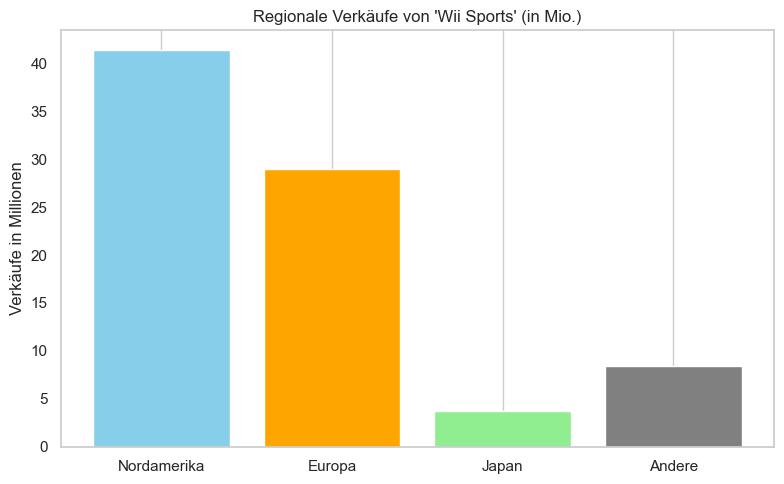

In [ ]:
# Top Spiel nach Verkäufen in den Regionen

regionen = ['Verkäufe_Nordamerika_Mio', 'Verkäufe_Europa_Mio', 'Verkäufe_Japan_Mio', 'Verkäufe_andere_Märkte_Mio']
werte = [top_spiel[spalte] for spalte in regionen]

plt.figure(figsize=(8, 5))
plt.bar(['Nordamerika', 'Europa', 'Japan', 'Andere'], werte, color=['skyblue', 'orange', 'lightgreen', 'grey'])
plt.title(f"Regionale Verkäufe von '{top_spiel['Spielname']}' (in Mio.)")
plt.ylabel("Verkäufe in Millionen")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

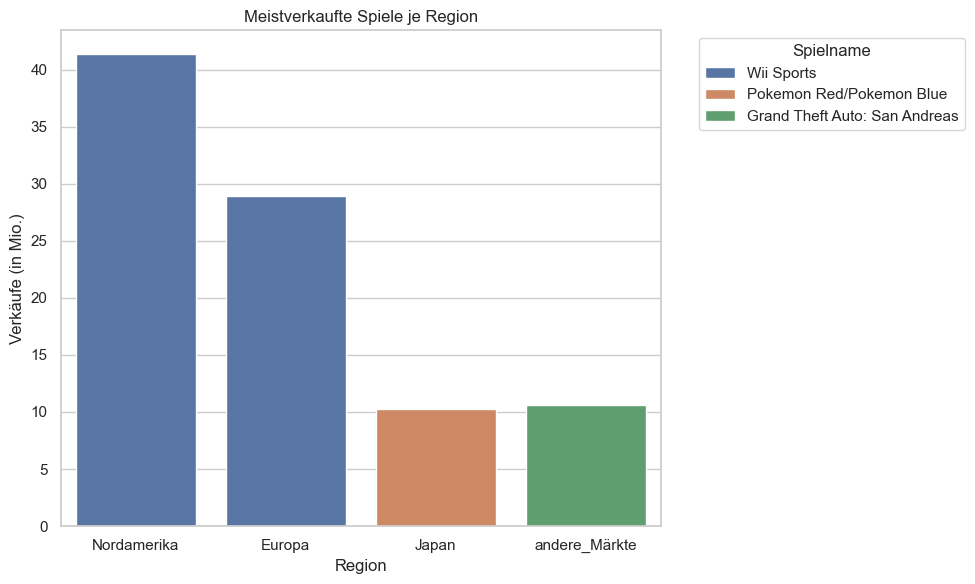

In [ ]:
# Top Spiel je Region (benutzt für die Präsentation)

df_top_spiele_region = pd.DataFrame(top_spiele_region)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_top_spiele_region, x='Region', y='Verkäufe', hue='Spielname', dodge=False)
plt.title('Meistverkaufte Spiele je Region')
plt.ylabel('Verkäufe (in Mio.)')
plt.xlabel('Region')
plt.legend(title='Spielname', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

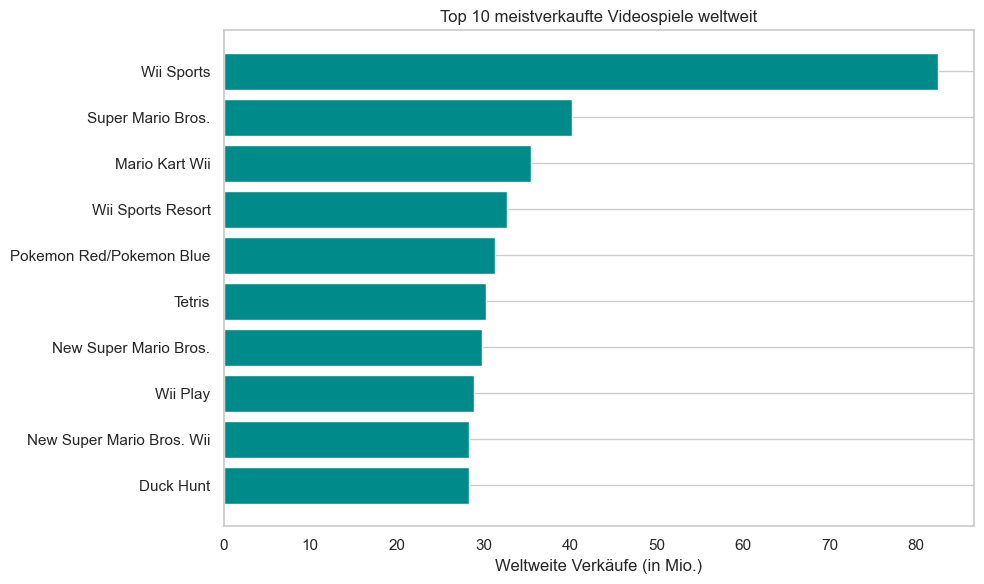

In [ ]:
# Top 10 Welweit_Verkäufe nach Spiel  (benutzt für die Präsentation)

# Balkendiagramm erstellen
plt.figure(figsize=(10, 6))
plt.barh(top10_vid_game['Spielname'], top10_vid_game['Weltweite_Verkäufe_Mio'], color='darkcyan')
plt.xlabel("Weltweite Verkäufe (in Mio.)")
plt.title("Top 10 meistverkaufte Videospiele weltweit")
plt.gca().invert_yaxis()  # Damit das meistverkaufte Spiel oben steht
plt.tight_layout()
plt.grid(axis='x')
plt.show()


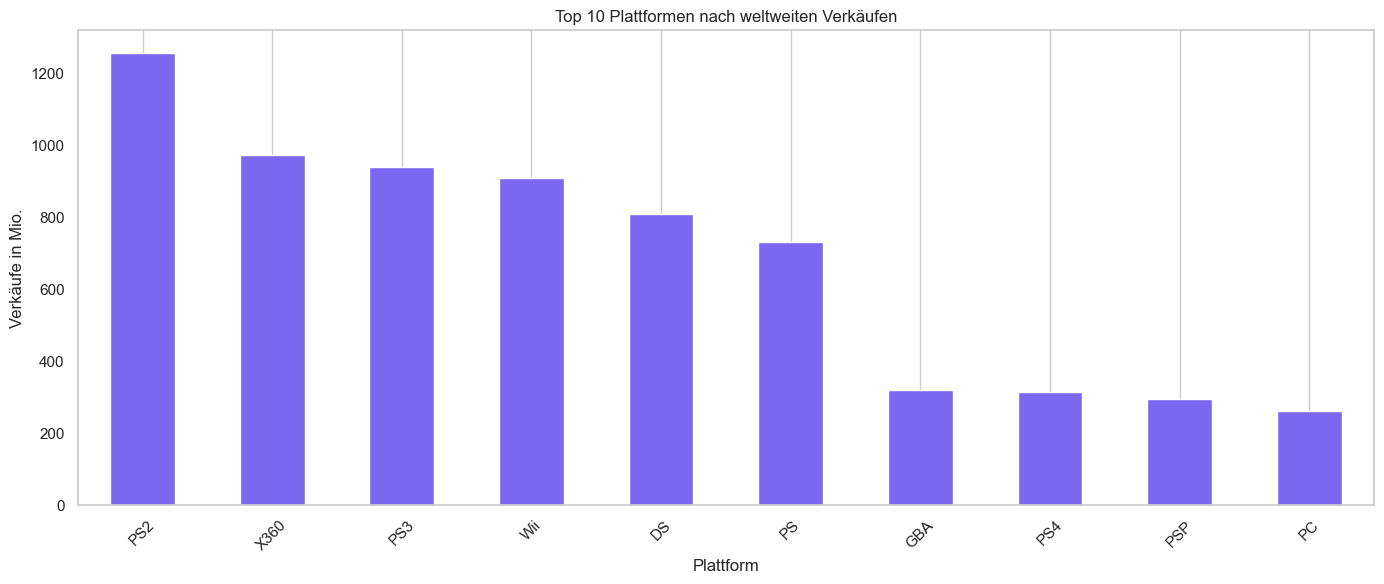

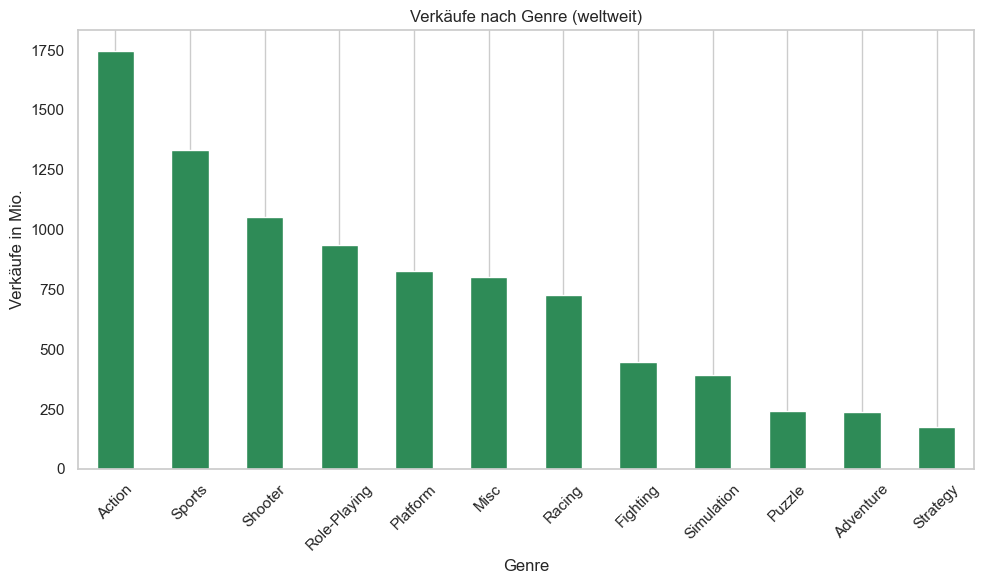

In [ ]:
# Gruppierung nach Genre und Plattform

# Plot: Plattformen
plt.figure(figsize=(14, 6))
plattformen.plot(kind='bar', color='mediumslateblue')
plt.title("Top 10 Plattformen nach weltweiten Verkäufen")
plt.ylabel("Verkäufe in Mio.")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plot: Genres
plt.figure(figsize=(10, 6))
genres.plot(kind='bar', color='seagreen')
plt.title("Verkäufe nach Genre (weltweit)")
plt.ylabel("Verkäufe in Mio.")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

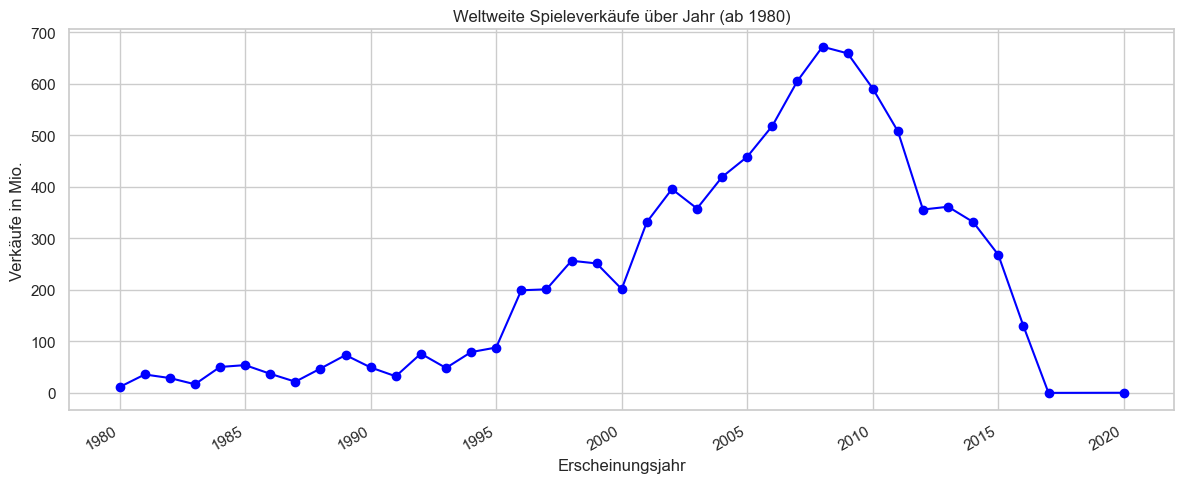

In [ ]:
# Welweite Verkäufe über Jahr (benutzt für die Präsentation)

# Plot
plt.figure(figsize=(12, 5))
verkaeufe_über_jahr.plot(kind='line', color='blue', marker='o')
plt.title("Weltweite Spieleverkäufe über Jahr (ab 1980)")
plt.ylabel("Verkäufe in Mio.")
plt.xlabel("Erscheinungsjahr")
plt.grid(True)
plt.tight_layout()
plt.show()


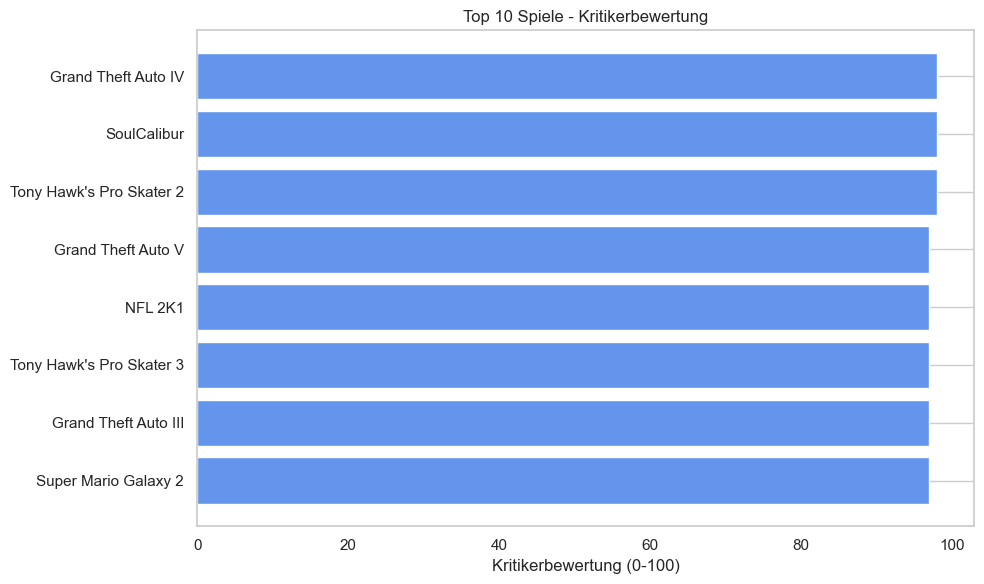

In [ ]:
# Spiele Bwertung (benutzt in der Präsentation)

# Plot Kritikerbewertungen (top 10)

plt.figure(figsize=(10, 6))
plt.barh(top10_kritiker['Spielname'], top10_kritiker['Kritiker_Bewertung'], color='cornflowerblue')
plt.xlabel("Kritikerbewertung (0-100)")
plt.title("Top 10 Spiele - Kritikerbewertung")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(axis='x')
plt.show()

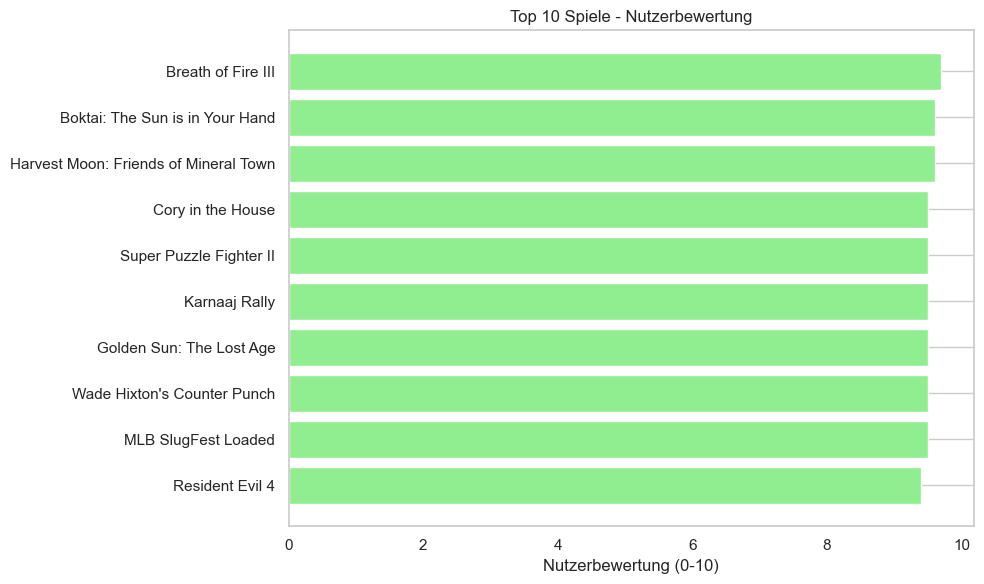

In [ ]:
# Plot Nutzerbewertungen(top 10)

plt.figure(figsize=(10, 6))
plt.barh(top10_nutzer['Spielname'], top10_nutzer['Nutzer_Bewertung'], color='lightgreen')
plt.xlabel("Nutzerbewertung (0-10)")
plt.title("Top 10 Spiele - Nutzerbewertung")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(axis='x')
plt.show()


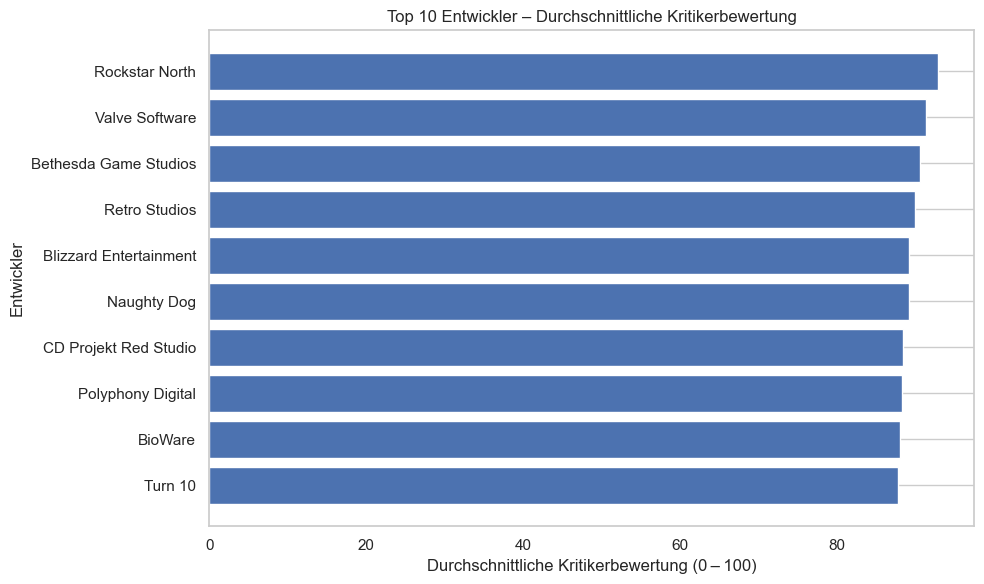

In [ ]:
# Top 10 Entwickler nach Kritikerbewertung

dev_10 = beliebte_entwickler.head(10)
plt.figure(figsize=(10, 6))
plt.barh(dev_10.index, dev_10["Durchschnittsbewertung"])
plt.xlabel("Durchschnittliche Kritikerbewertung (0 – 100)")
plt.ylabel("Entwickler")
plt.title("Top 10 Entwickler – Durchschnittliche Kritikerbewertung")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()


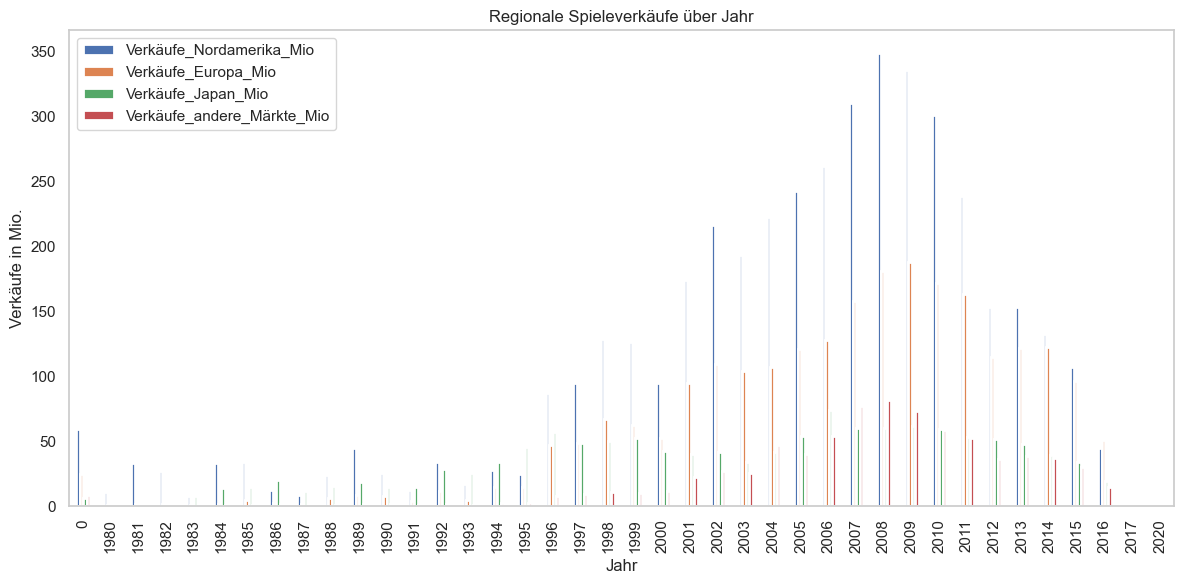

In [ ]:
# Verkäufe nach Region über Jahr (in der Präsentation)

# Plotten
plt.figure(figsize=(12, 6))
verkaeufe_region_jahr.plot.bar(ax=plt.gca(), linewidth=2)
plt.title('Regionale Spieleverkäufe über Jahr')
plt.xlabel('Jahr')
plt.ylabel('Verkäufe in Mio.')
plt.grid(False)
plt.tight_layout()
plt.show()

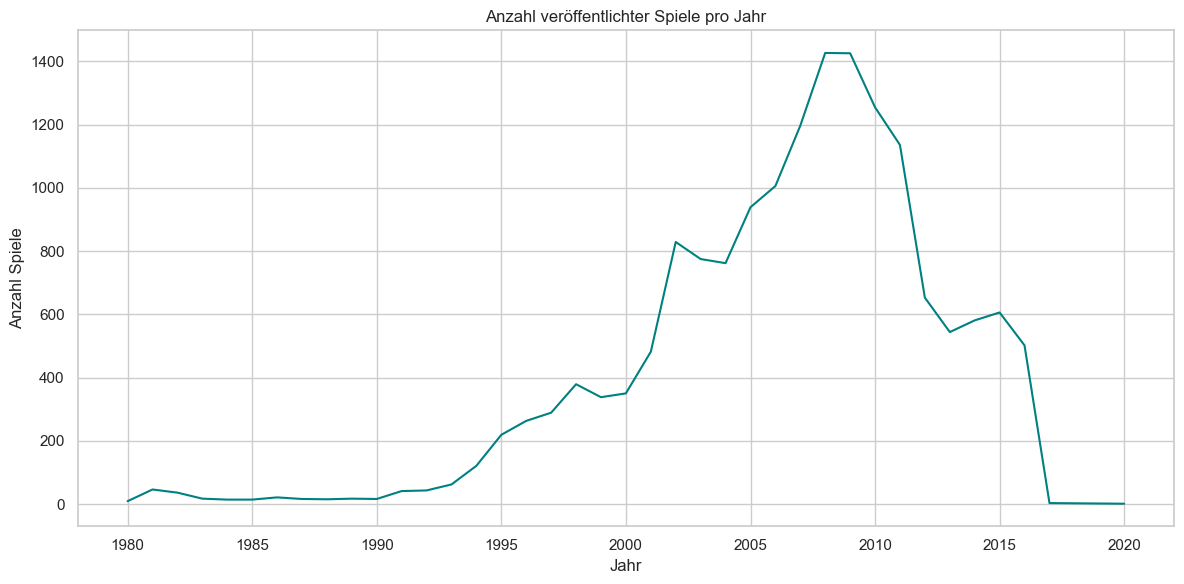

In [ ]:
# Anzahl veröffentlichter Spiele über Jahr (benutzt inder Präsentation )


plt.figure(figsize=(12, 6))
plt.plot(spiele_pro_jahr_df["Jahr"], spiele_pro_jahr_df["Anzahl_Spiele"], color='teal')
plt.title("Anzahl veröffentlichter Spiele pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Anzahl Spiele")
plt.grid(True)
plt.tight_layout()
plt.show()


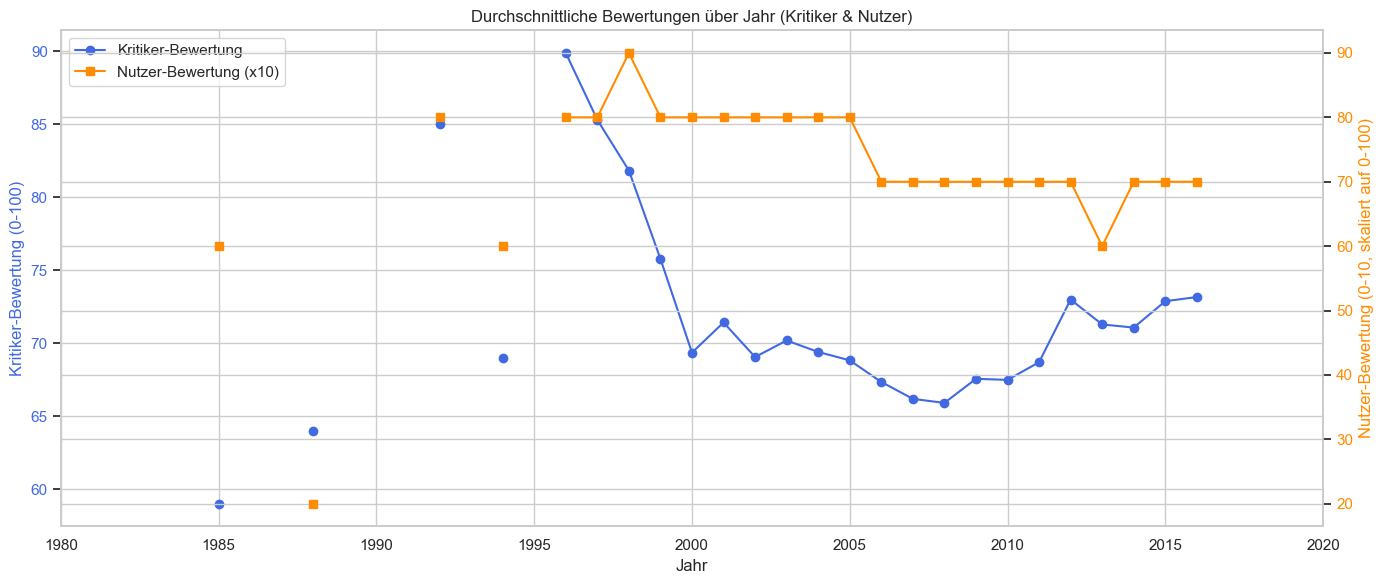

In [ ]:
# Verbesserte Darstellung: Durchschnittliche Bewertungen über Jahr

fig, ax1 = plt.subplots(figsize=(14, 6))

# Kritikerbewertung (0-100)
ax1.plot(kritiker_über_jahr.index, kritiker_über_jahr.values, color='royalblue', marker='o', label='Kritiker-Bewertung')
ax1.set_ylabel('Kritiker-Bewertung (0-100)', color='royalblue')
ax1.set_xlabel('Jahr')
ax1.set_xlim(1980, max(kritiker_über_jahr.index.max(), nutzer_über_jahr.index.max()))
ax1.tick_params(axis='y', labelcolor='royalblue')

# Nutzerbewertung (0-10), auf 0-100 skaliert
ax2 = ax1.twinx()
ax2.plot(nutzer_über_jahr.index, nutzer_über_jahr.values * 10, color='darkorange', marker='s', label='Nutzer-Bewertung (x10)')
ax2.set_ylabel('Nutzer-Bewertung (0-10, skaliert auf 0-100)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legenden
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Durchschnittliche Bewertungen über Jahr (Kritiker & Nutzer)')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

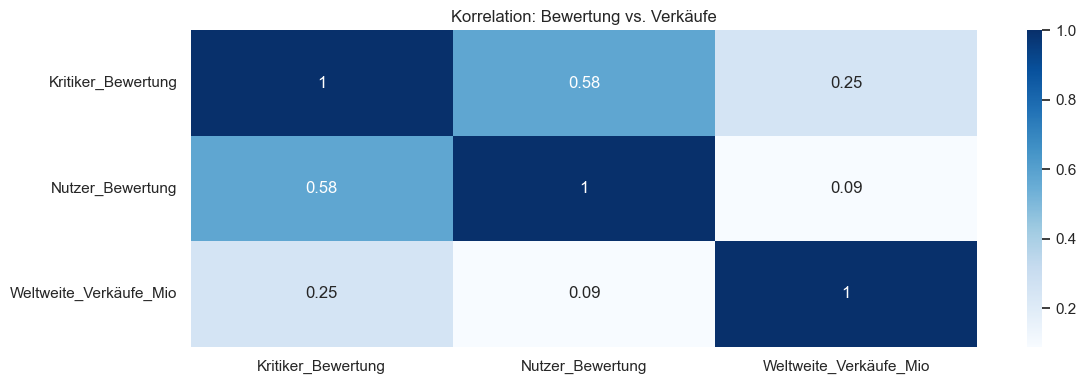

In [ ]:
# Korrelation zwischen Bewertungen und weltweiten Verkäufen

plt.figure(figsize=(12, 4))
sns.heatmap(korrelation, annot=True, cmap='Blues')
plt.title('Korrelation: Bewertung vs. Verkäufe')
plt.tight_layout()
plt.show()

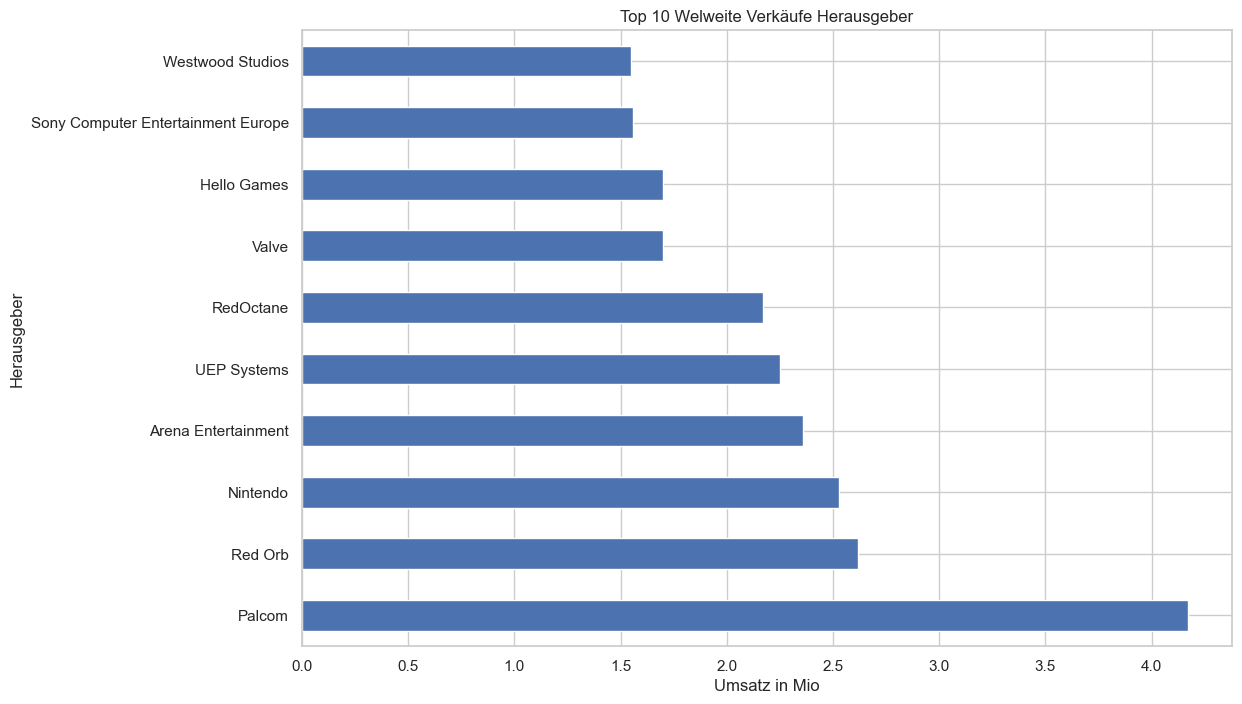

In [ ]:
# Top_10 Welweite Verkäufer Herausgeber 

top_herausgeber.plot.barh(figsize=(12, 8))
plt.title('Top 10 Welweite Verkäufe Herausgeber')
plt.xlabel('Umsatz in Mio')
plt.ylabel('Herausgeber')
plt.show()

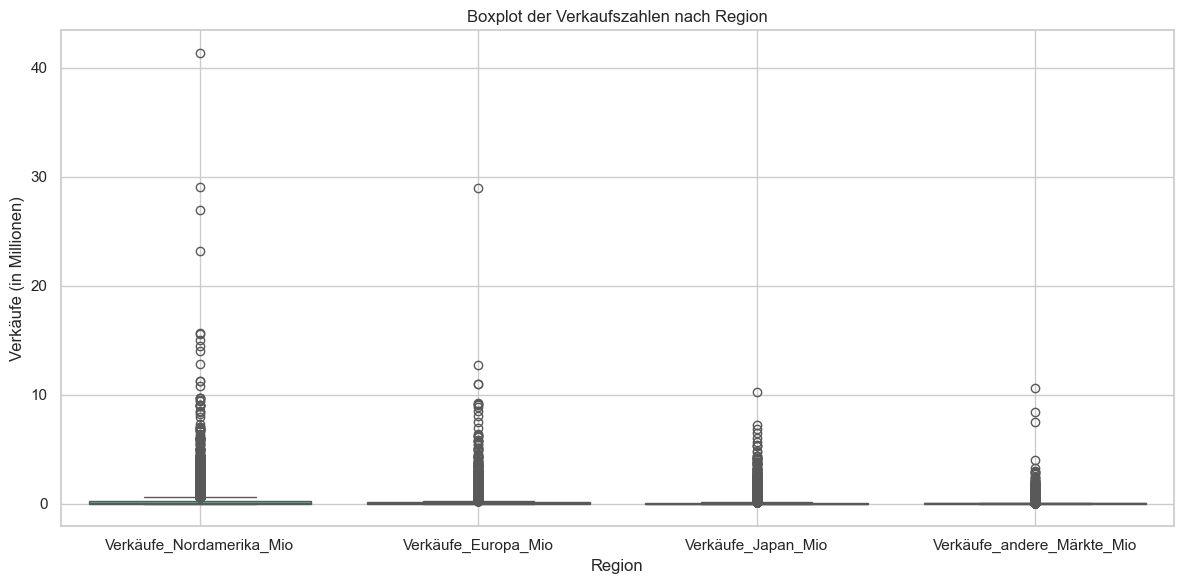

In [ ]:
# Verteillung nach Region (benutzt in der Präsentation)

df_melted = vid_game_sales.melt(value_vars=region_cols, var_name='Region', value_name='Verkäufe_Mio')

# Plot-Stil

# Boxplot erstellen
plt.figure(figsize=(12, 6))
#sns.boxplot(data=df_melted, x='Region', y='Verkäufe_Mio', palette='Set2')
sns.boxplot(data=df_melted, x='Region', y='Verkäufe_Mio', hue='Region', palette='Set2', legend=False)

plt.title("Boxplot der Verkaufszahlen nach Region")
plt.xlabel("Region")
plt.ylabel("Verkäufe (in Millionen)")
plt.grid(True)
plt.tight_layout()
plt.show()

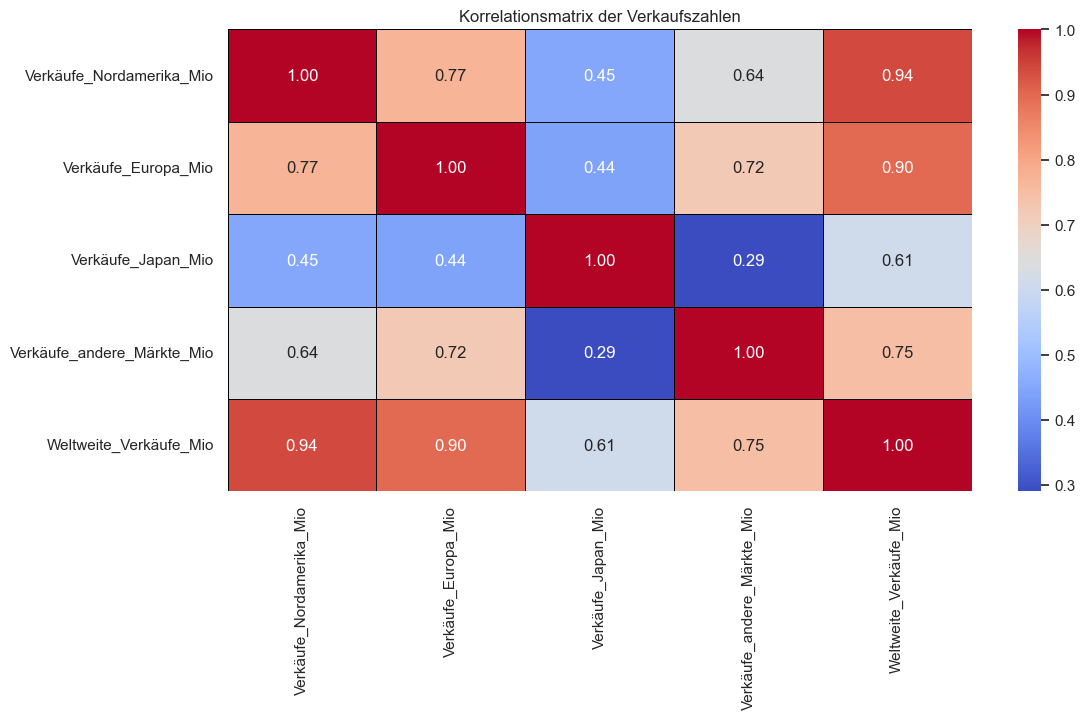

In [ ]:
# Korrelationsanalyse (benutzt in der Präsentation)

plt.figure(figsize=(12, 6))
sns.heatmap(korr_verkaeufe, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Korrelationsmatrix der Verkaufszahlen')
plt.show()

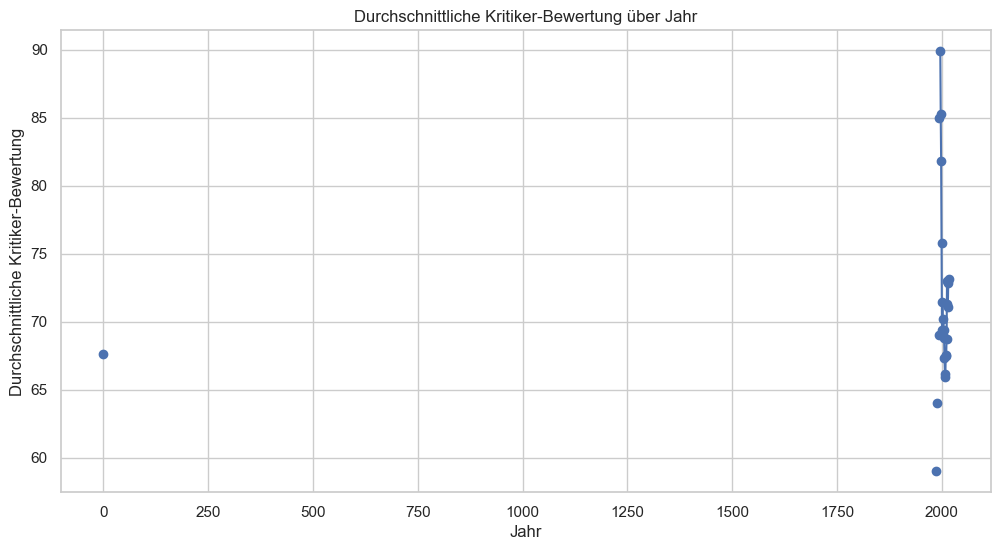

In [ ]:
# Kritiker-Bewertung für Spiele über Jahr

plt.figure(figsize=(12, 6))
kritiker_über_jahr.plot.line(marker='o')
plt.title('Durchschnittliche Kritiker-Bewertung über Jahr')
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche Kritiker-Bewertung')
plt.grid(True)
plt.show()

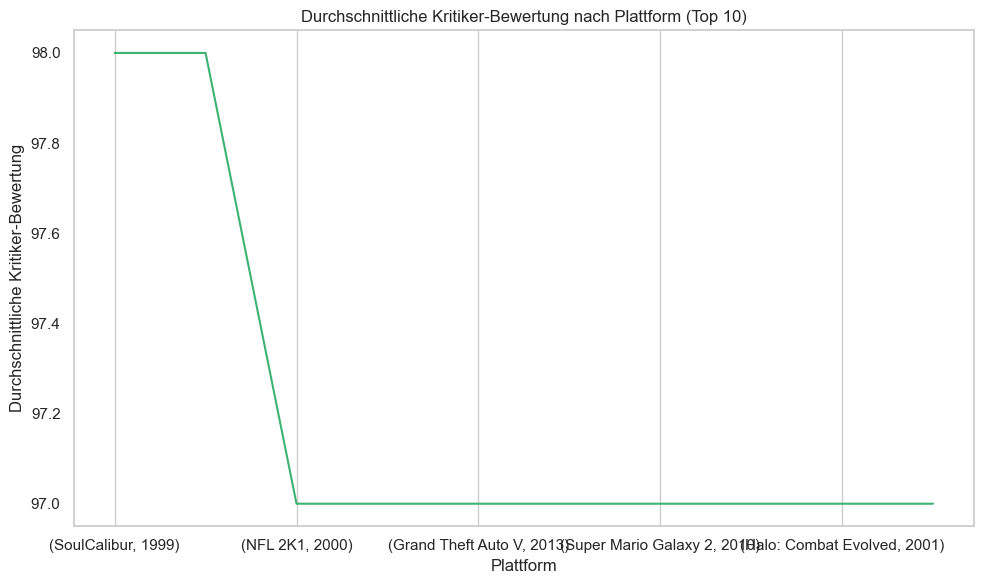

In [ ]:
# Kritiker Bewertung nach Plattform (top 10)

plt.figure(figsize=(10, 6))
kritiker_plattform.plot.line(color='mediumseagreen')
plt.title('Durchschnittliche Kritiker-Bewertung nach Plattform (Top 10)')
plt.xlabel('Plattform')
plt.ylabel('Durchschnittliche Kritiker-Bewertung')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

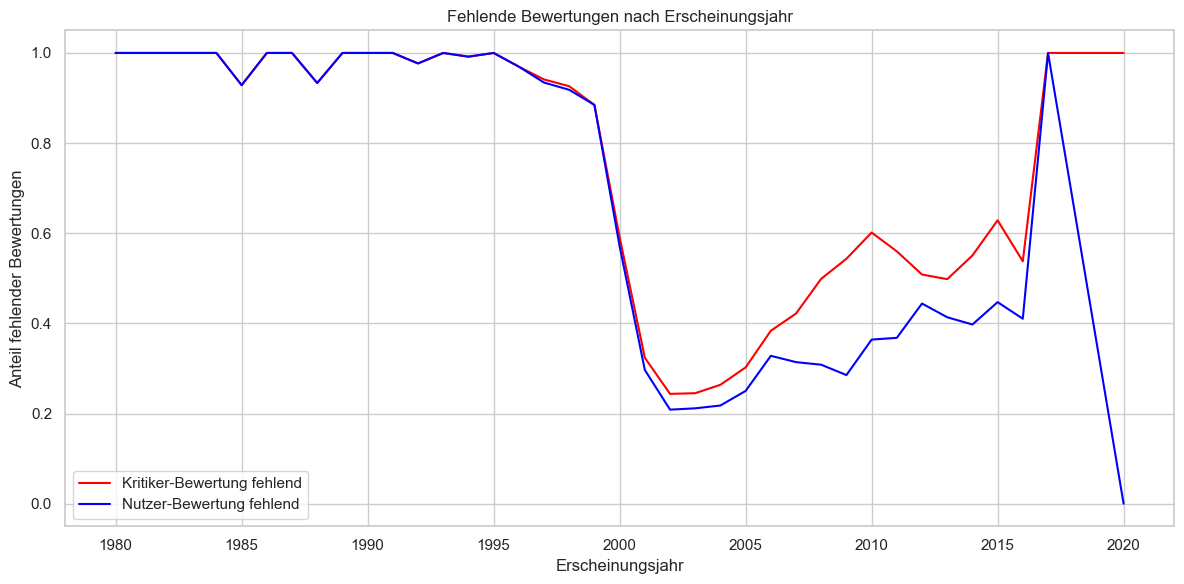

In [ ]:
# Fehlende Bewertungen nach Erscheinungsjahr (benutzt in der Präsentation)

plt.figure(figsize=(12, 6))
plt.plot(kritiker_fehlend.index, kritiker_fehlend.values, label='Kritiker-Bewertung fehlend', color='red')
plt.plot(nutzer_fehlend.index, nutzer_fehlend.values, label='Nutzer-Bewertung fehlend', color='blue')
plt.xlabel("Erscheinungsjahr")
plt.ylabel("Anteil fehlender Bewertungen")
plt.title("Fehlende Bewertungen nach Erscheinungsjahr")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()